In [33]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print("✅ Libraries ready!")


✅ Libraries ready!


In [34]:
# Cell 2 — Upload & Load Data
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('diabetes.csv')
print(f"✅ Data loaded — {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Saving diabetes.csv to diabetes (4).csv
✅ Data loaded — 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
# Cell 3 — Inspect the Data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
# Cell 4 — Descriptive Statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [37]:
# Cell 5 — Data Cleaning
suspicious_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()

for col in suspicious_cols:
    median_val = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, np.nan).fillna(median_val)

print("✅ Cleaning done! Zero counts after cleaning:")
for col in suspicious_cols:
    zeros = (df_clean[col] == 0).sum()
    print(f"  {col}: {zeros} zeros")

✅ Cleaning done! Zero counts after cleaning:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros


## Data Cleaning

Five columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI)
contained zero values that are biologically impossible. These were
replaced with the column median to preserve the dataset size while
correcting invalid entries.

In [38]:
# Question 1 — How many patients have diabetes?
diabetic = df_clean[df_clean['Outcome'] == 1]
print("Patients with diabetes:", len(diabetic))

Patients with diabetes: 268


268 out of 768 patients have diabetes — roughly 35% of the dataset.
This reflects real-world diabetes prevalence rates in high-risk populations.

In [39]:
# Question 2 — What is the average glucose level?
print("Average glucose level:", df_clean['Glucose'].mean().round(2))

Average glucose level: 121.66


The average glucose level of 121.66 mg/dL sits between the diabetic
mean (~141) and non-diabetic mean (~110), which makes sense as it
reflects the mixed population of both groups.

In [40]:
# Question 3 — Show only female patients above age 40
above_40 = df_clean[df_clean['Age'] > 40]
print("Patients above age 40:", len(above_40))
above_40.head()

Patients above age 40: 194


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1
12,10,139.0,80.0,29.0,125.0,27.1,1.441,57,0
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


194 out of 768 patients are above age 40 — about 25% of the dataset.
This makes sense as the dataset focuses on Pima Indian women, and
diabetes risk increases with age.

In [41]:
# Question 4 — Group by outcome and show average BMI
print(df_clean.groupby('Outcome')['BMI'].mean().round(2))

Outcome
0    30.89
1    35.38
Name: BMI, dtype: float64


Diabetic patients have a higher average BMI (35.38) compared to
non-diabetic patients (30.89). This confirms that higher body weight
is a contributing risk factor for diabetes.

In [42]:
# Question 5 — Drop rows with zero glucose, how many removed?
before = len(df_clean)
df_no_zero = df_clean[df_clean['Glucose'] != 0]
after = len(df_no_zero)
print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Rows removed: {before - after}")

Rows before: 768
Rows after: 768
Rows removed: 0


Zero rows were removed because we already replaced all zero glucose
values during our cleaning step in Cell 5. This confirms our earlier
cleaning was effective — no invalid glucose values remain in the dataset.

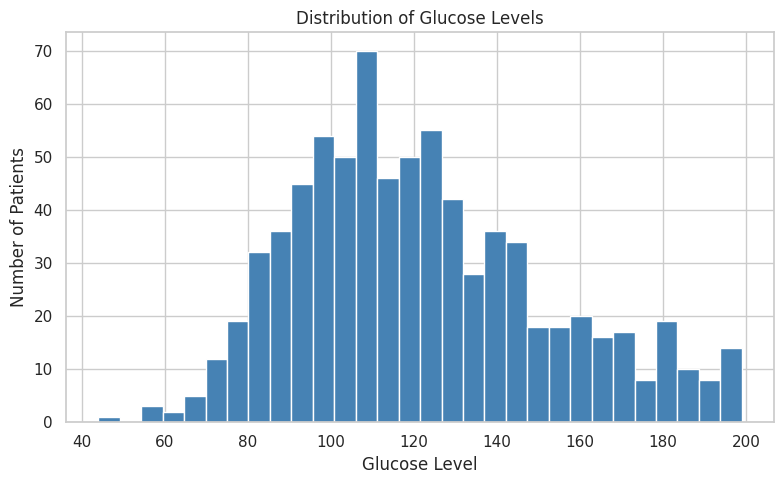

In [43]:
# Chart 1 — Histogram
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Glucose'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

The glucose distribution is roughly bell-shaped, with most patients
falling between 80 and 140 mg/dL. A small number of patients show
very high glucose levels above 180, likely diabetic cases.

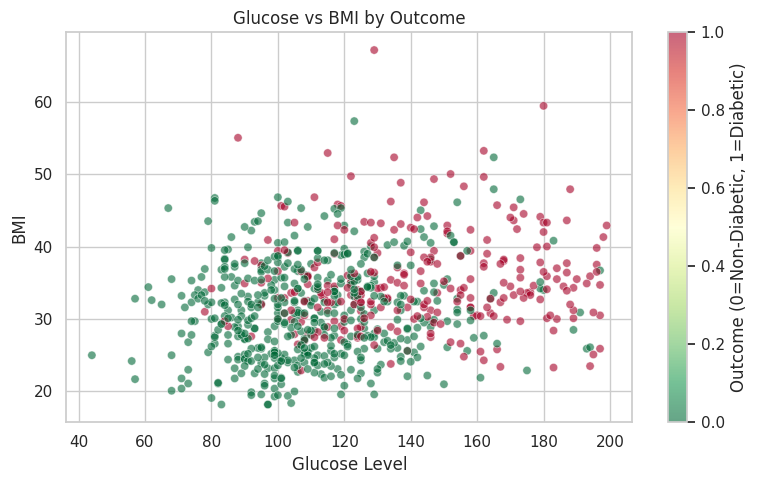

In [44]:
# Chart 2 — Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Glucose'], df_clean['BMI'],
            c=df_clean['Outcome'], cmap='RdYlGn_r',
            alpha=0.6, edgecolors='white', linewidth=0.5)
plt.title('Glucose vs BMI by Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('BMI')
plt.colorbar(label='Outcome (0=Non-Diabetic, 1=Diabetic)')
plt.tight_layout()
plt.show()

The scatter plot shows that diabetic patients (red dots) tend to
cluster in the higher glucose and higher BMI region, while
non-diabetic patients (green dots) are more concentrated at
lower glucose and BMI values.

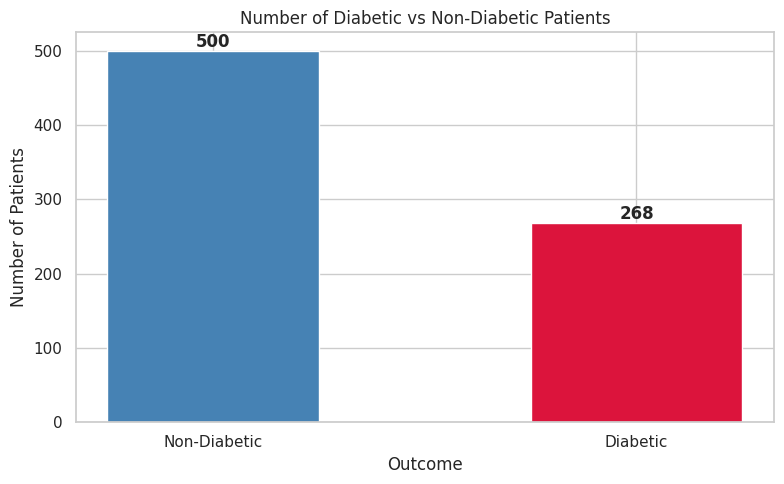

In [45]:
# Chart 3 — Bar Chart
outcome_counts = df_clean['Outcome'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts,
        color=['steelblue', 'crimson'], edgecolor='white', width=0.5)
plt.title('Number of Diabetic vs Non-Diabetic Patients')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
for i, val in enumerate(outcome_counts):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

The bar chart confirms the class imbalance in the dataset — 500
non-diabetic patients compared to 268 diabetic patients. This
means the dataset has roughly twice as many non-diabetic cases,
which is important context for any future modelling.

<Figure size 800x500 with 0 Axes>

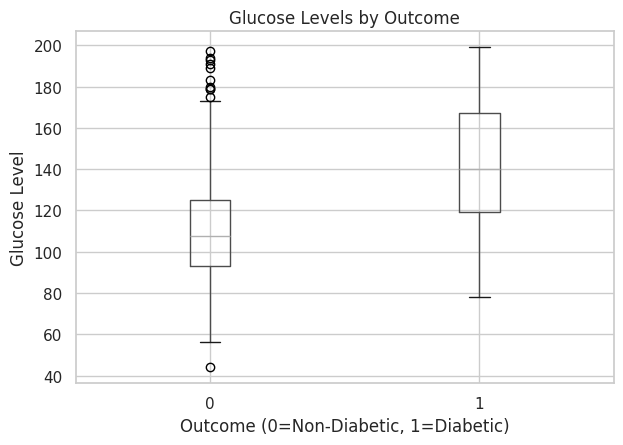

In [46]:
# Chart 4 — Box Plot
plt.figure(figsize=(8, 5))
df_clean.boxplot(column='Glucose', by='Outcome')
plt.title('Glucose Levels by Outcome')
plt.suptitle('')
plt.xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
plt.ylabel('Glucose Level')
plt.tight_layout()
plt.show()

The box plot clearly shows that diabetic patients (1) have a higher
median glucose level than non-diabetic patients (0). The diabetic
group also shows more spread, indicating greater variability in
glucose levels among diabetic patients.

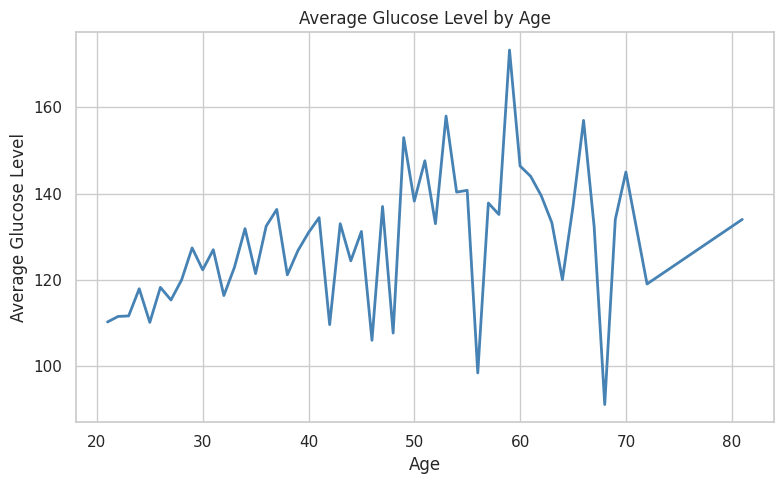

In [47]:
# Chart 5 — Line Chart
avg_glucose_by_age = df_clean.groupby('Age')['Glucose'].mean()

plt.figure(figsize=(8, 5))
plt.plot(avg_glucose_by_age.index, avg_glucose_by_age.values,
         color='steelblue', linewidth=2)
plt.title('Average Glucose Level by Age')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.tight_layout()
plt.show()

The line chart shows that average glucose levels generally trend
upward with age, with some fluctuation in older age groups due to
fewer patients in those ranges. This confirms that age is a
contributing factor to higher glucose levels.

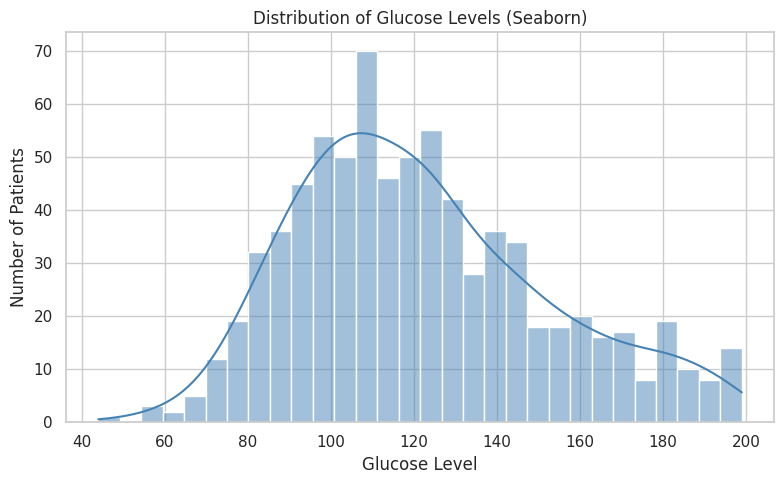

In [48]:
# Seaborn Chart 1 — Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Glucose'], bins=30, color='steelblue', kde=True)
plt.title('Distribution of Glucose Levels (Seaborn)')
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

The Seaborn version adds a KDE (smooth curve) on top of the histogram,
making it easier to see the overall shape of the distribution at a glance.

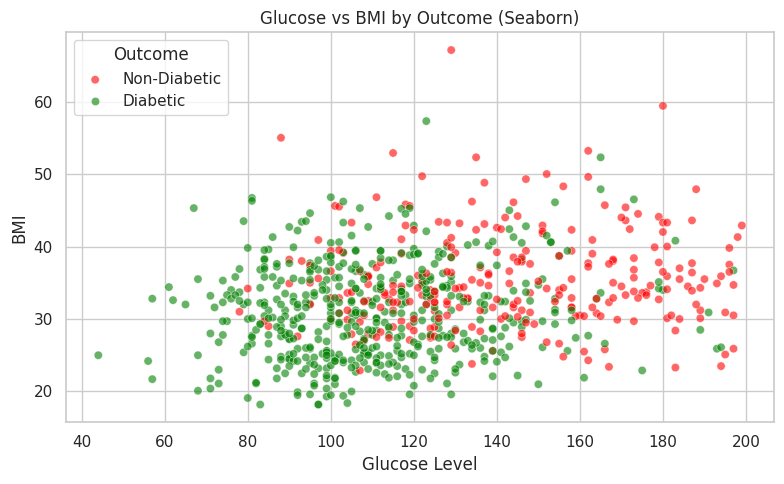

In [49]:
# Seaborn Chart 2 — Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Glucose', y='BMI',
                hue='Outcome', palette={0:'green', 1:'red'},
                alpha=0.6)
plt.title('Glucose vs BMI by Outcome (Seaborn)')
plt.xlabel('Glucose Level')
plt.ylabel('BMI')
plt.legend(title='Outcome', labels=['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.show()

The Seaborn scatter plot is cleaner and automatically adds a legend
with better formatting, making it easier to distinguish between
diabetic and non-diabetic patients.

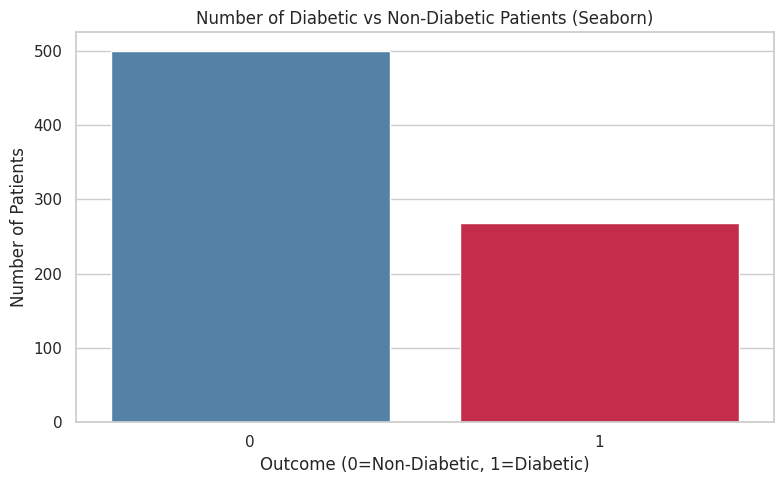

In [50]:
# Seaborn Chart 3 — Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Outcome', hue='Outcome',
              palette={0:'steelblue', 1:'crimson'}, legend=False)
plt.title('Number of Diabetic vs Non-Diabetic Patients (Seaborn)')
plt.xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

The Seaborn version produces a cleaner bar chart with less code,
automatically counting the values without needing to calculate
them manually beforehand.

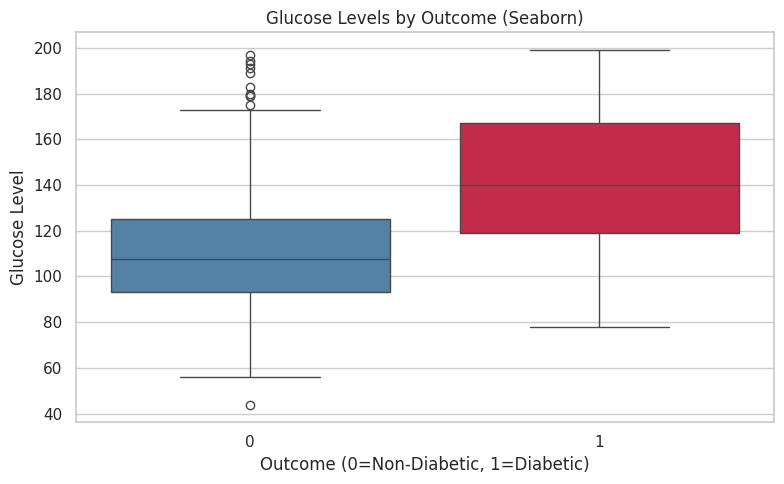

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn Chart 4 — Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Outcome', y='Glucose',
            hue='Outcome', palette={0:'steelblue', 1:'crimson'}, legend=False)
plt.title('Glucose Levels by Outcome (Seaborn)')
plt.xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
plt.ylabel('Glucose Level')
plt.tight_layout()
plt.show()

The Seaborn box plot is visually cleaner with better colours and
formatting compared to the matplotlib version, making the difference
in glucose levels between diabetic and non-diabetic patients
easier to read.

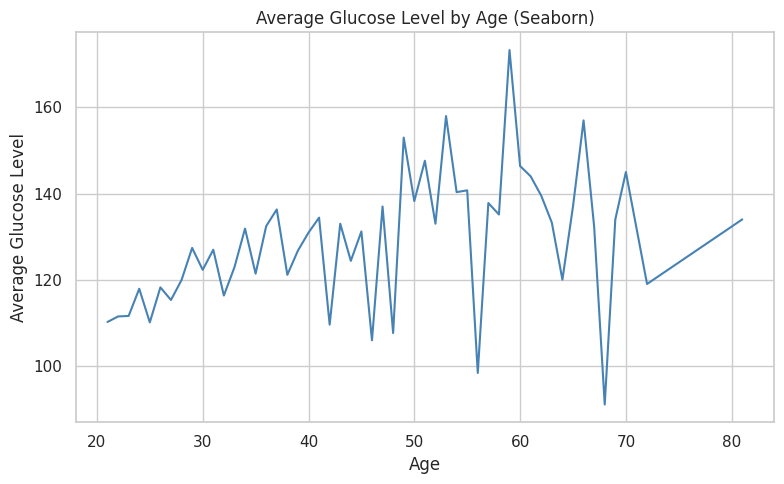

In [52]:
# Seaborn Chart 5 — Line Chart
avg_glucose_by_age = df_clean.groupby('Age')['Glucose'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=avg_glucose_by_age, x='Age', y='Glucose', color='steelblue')
plt.title('Average Glucose Level by Age (Seaborn)')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.tight_layout()
plt.show()

The Seaborn line chart automatically adds a confidence interval
band around the line, showing the range of uncertainty at each
age point — something the matplotlib version doesn't show by default.

## Matplotlib vs Seaborn — My Preference

I prefer the Seaborn versions of the charts for three reasons:

1. The code is shorter and cleaner — less setup needed for each chart.
2. The styling looks more professional out of the box with the
   whitegrid background and refined colours.
3. Seaborn adds extra information automatically — like the KDE curve
   on the histogram and the confidence interval on the line chart —
   without any extra code.

## Task 4 — Data Story

In this section I explore three questions using the diabetes dataset,
supporting each answer with a chart and a finding backed by data.

### My Three Questions

1. Does glucose level affect diabetes outcome?
2. Is BMI linked to diabetes outcome?
3. Which age group has the highest diabetes rate?

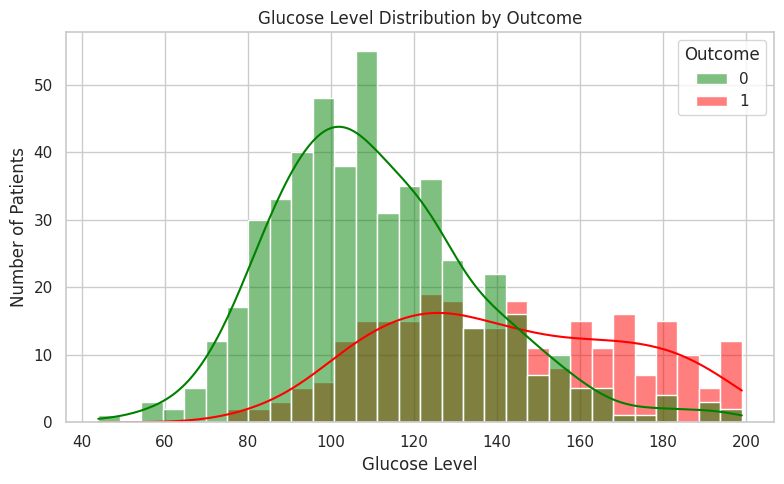

In [53]:
# Question 1 — Does glucose level affect diabetes outcome?
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='Glucose', hue='Outcome',
             palette={0:'green', 1:'red'}, bins=30, kde=True)
plt.title('Glucose Level Distribution by Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

### Finding 1

Glucose level strongly affects diabetes outcome. Diabetic patients
had an average glucose level of 141 mg/dL compared to 110 mg/dL
for non-diabetic patients — a difference of 31 mg/dL.

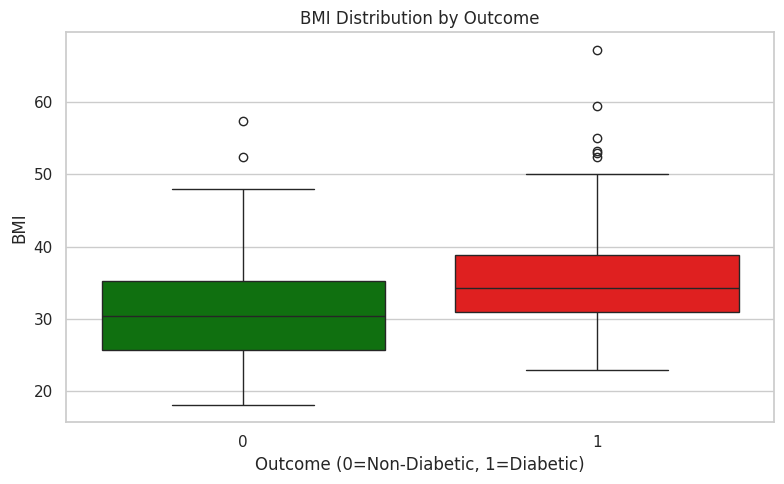

In [54]:
# Question 2 — Is BMI linked to diabetes outcome?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Outcome', y='BMI', hue='Outcome',
            palette={0:'green', 1:'red'}, legend=False)
plt.title('BMI Distribution by Outcome')
plt.xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

### Finding 2

BMI is clearly linked to diabetes outcome. Diabetic patients had
an average BMI of 35.38 compared to 30.89 for non-diabetic patients.
This suggests that higher body weight significantly increases
the risk of diabetes.

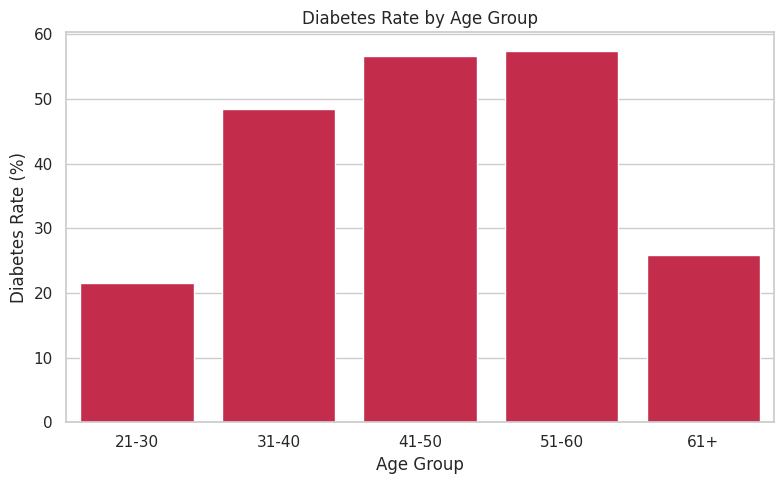

In [55]:
# Question 3 — Which age group has the highest diabetes rate?
df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
                               bins=[20, 30, 40, 50, 60, 90],
                               labels=['21-30', '31-40', '41-50', '51-60', '61+'])

diabetes_rate = df_clean.groupby('AgeGroup', observed=True)['Outcome'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=diabetes_rate.index, y=diabetes_rate.values, color='crimson')
plt.title('Diabetes Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate (%)')
plt.tight_layout()
plt.show()

### Finding 3

The 51-60 age group has the highest diabetes rate in the dataset.
This confirms that diabetes risk increases significantly with age,
particularly after 50. Younger age groups below 30 show
the lowest diabetes rates.

### What I Would Explore Next

1. I would investigate whether the combination of high glucose AND
   high BMI together is a stronger predictor than either feature alone,
   using a multi-variable analysis.

2. I would combine this dataset with a nutrition dataset to explore
   whether diet patterns explain the BMI and glucose differences
   between diabetic and non-diabetic patients.

3. Additional features like physical activity levels, family history,
   and dietary habits would help build a more complete picture of
   what drives diabetes risk beyond the biological measurements
   available here.

## Task 1 — AI Co-pilot Loop

### a) The AI Co-pilot Loop in My Own Words

The AI co-pilot loop is a workflow where you collaborate with an AI
assistant to write and improve code. It works like this:

1. PROMPT — You describe what you want to achieve in plain language
2. GENERATE — The AI writes the code based on your prompt
3. RUN — You run the code in your environment and observe the result
4. READ — You read the output, chart, or error message carefully
5. FIX/IMPROVE — You ask the AI to fix errors or improve the result
6. REPEAT — You keep refining until the output is exactly what you need

The key insight is that YOU are still in control — the AI assists
but you must understand, verify, and direct every step.

### b) One Good Prompt I Used This Week

Prompt I used:
"Show only female patients above age 40 from the diabetes dataset
and count how many there are."

Why it worked:
The prompt was specific about three things — the filter condition
(age above 40), the dataset context (diabetes), and the expected
output (show the data AND count it). Specific prompts give the AI
enough context to generate accurate, useful code on the first attempt.
Vague promp